In [32]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np

#Importation de la librairie plotly express
import plotly.express as px
import matplotlib.pyplot as plt

In [33]:

#Importation du fichier erp.xlsx
df_customers_raw = pd.read_csv("data/customers.csv", sep=";", encoding='latin-1')
#Importation du fichier liaison.xlsx
df_products_raw = pd.read_csv('data/products.csv',sep=";", encoding='latin-1')
#Importation du fichier web.xlsx
df_transactions_raw = pd.read_csv('data/transactions.csv', encoding='latin-1', sep=";", on_bad_lines='warn')

C:\Users\User\AppData\Local\Temp\ipykernel_28900\3589511456.py:6: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions_raw = pd.read_csv('data/transactions.csv', encoding='latin-1', sep=";", on_bad_lines='warn')


In [34]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s)".format(df_customers_raw.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_customers_raw.shape[1]))

print("Le tableau comporte {} observation(s)".format(df_products_raw.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_products_raw.shape[1]))

print("Le tableau comporte {} observation(s) ".format(df_transactions_raw.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_transactions_raw.shape[1]))

Le tableau comporte 8621 observation(s)
Le tableau comporte 3 colonne(s)
Le tableau comporte 3286 observation(s)
Le tableau comporte 3 colonne(s)
Le tableau comporte 1048575 observation(s) 
Le tableau comporte 4 colonne(s)


In [35]:


df_transactions_raw["date"] = pd.to_datetime(df_transactions_raw["date"])
df_transactions_raw = df_transactions_raw.dropna(how="all")

df_customers_raw.columns = df_customers_raw.columns.str.replace('ï»¿','')
df_transactions_raw.columns = df_transactions_raw.columns.str.replace('ï»¿','')
df_products_raw.columns = df_products_raw.columns.str.replace('ï»¿','')

df_customers_raw.info()
df_transactions_raw.info()
df_products_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 26.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   i

In [36]:
df_customers_raw.duplicated().sum()
df_products_raw.duplicated().sum()
df_transactions_raw.duplicated().sum()

np.int64(0)

In [37]:
df_customers_raw["age"] = 2024 - df_customers_raw["birth"]

df_customers_raw[df_customers_raw["age"] > 100]


,client_id,sex,birth,age


In [38]:
df_products_raw[df_products_raw["price"] < 0]


,id_prod,price,categ


In [39]:
df_customers_raw.isnull().sum()
df_products_raw.isnull().sum()
df_transactions_raw.isnull().sum()


id_prod       0
date          0
session_id    0
client_id     0
dtype: int64

In [40]:
df_customers_raw.duplicated().sum()
df_products_raw.duplicated().sum()
df_transactions_raw.duplicated().sum()

np.int64(0)

In [41]:
df_custom_transac = df_transactions_raw.merge(
    df_customers_raw,
    on="client_id",
    how="left"
)

df_all = df_custom_transac.merge(
    df_products_raw,
    on="id_prod",
    how="left"
)

df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
 4   sex         687534 non-null  object        
 5   birth       687534 non-null  int64         
 6   age         687534 non-null  int64         
 7   price       687534 non-null  float64       
 8   categ       687534 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 47.2+ MB


In [42]:
df_all["ca"] = df_all["price"]

ca_journalier = df_all.groupby(df_all["date"].dt.date)["ca"].sum()

ca_journalier = ca_journalier.reset_index()
ca_journalier.columns = ["date", "ca"]

ca_journalier["mm_7j"] = ca_journalier["ca"].rolling(window=7).mean()

print(ca_journalier)

           date        ca         mm_7j
0    2021-03-01  16565.22           NaN
1    2021-03-02  15486.45           NaN
2    2021-03-03  15198.69           NaN
3    2021-03-04  15196.07           NaN
4    2021-03-05  17471.37           NaN
..          ...       ...           ...
725  2023-02-24  15207.89  16488.778571
726  2023-02-25  15761.25  16006.747143
727  2023-02-26  16304.72  16035.021429
728  2023-02-27  19170.81  16487.570000
729  2023-02-28  18105.15  16513.984286

[730 rows x 3 columns]


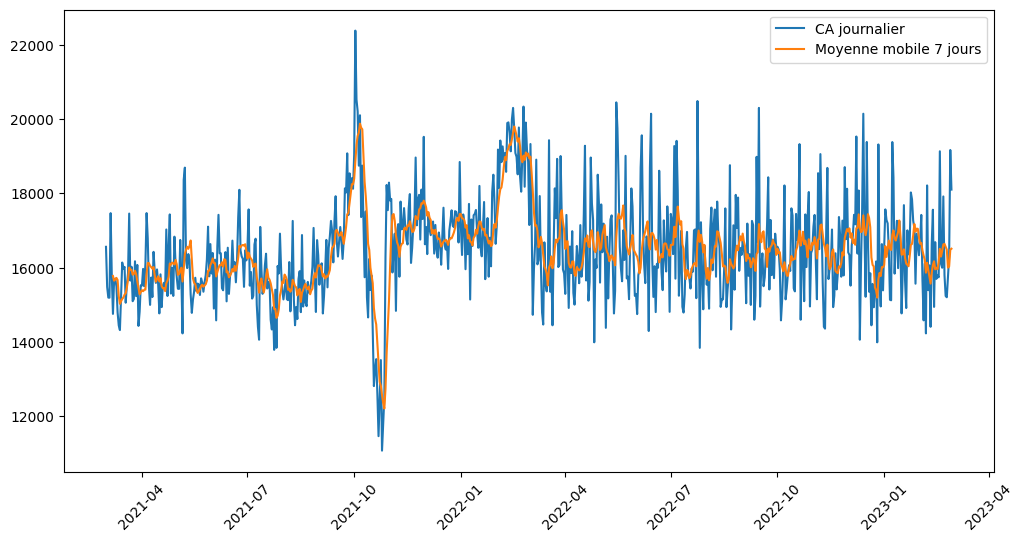

In [43]:
plt.figure(figsize=(12,6))

plt.plot(ca_journalier["date"], ca_journalier["ca"], label="CA journalier")
plt.plot(ca_journalier["date"], ca_journalier["mm_7j"], label="Moyenne mobile 7 jours")

plt.legend()
plt.xticks(rotation=45)
plt.show()

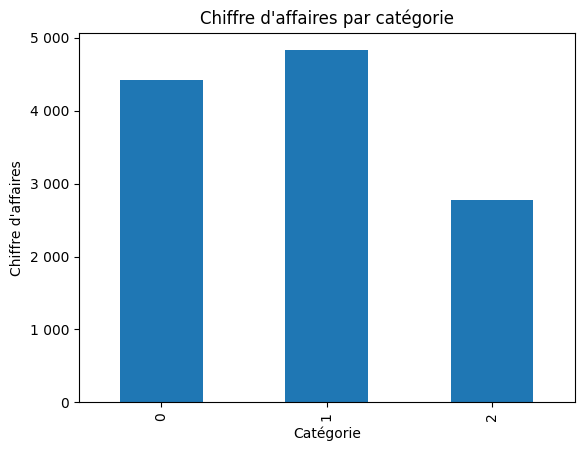

In [44]:
ca_categorie = df_all.groupby("categ")["ca"].sum()

ca_categorie.plot(kind="bar", legend=False, style="plain")
import matplotlib.ticker as mtick

ax = ca_categorie.plot(kind="bar", legend=False)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"{int(x/1000):,}".replace(",", " ")))

plt.title("Chiffre d'affaires par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Chiffre d'affaires")
plt.show()

categ
1          NaN
0    -8.449775
2   -37.094021
Name: ca, dtype: float64


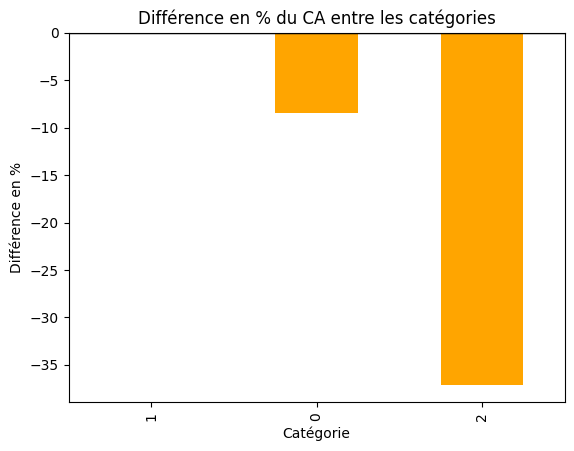

In [45]:


# Somme du CA par catégorie
ca_categorie = df_all.groupby("categ")["ca"].sum().sort_values(ascending=False)

# Différence en % par rapport à la catégorie précédente
diff_pct = ca_categorie.pct_change() * 100

# Affichage
print(diff_pct)

# Graphique
diff_pct.plot(kind="bar", color="orange", legend=False)
plt.title("Différence en % du CA entre les catégories")
plt.xlabel("Catégorie")
plt.ylabel("Différence en %")
plt.axhline(0, color="black", linewidth=1)
plt.show()

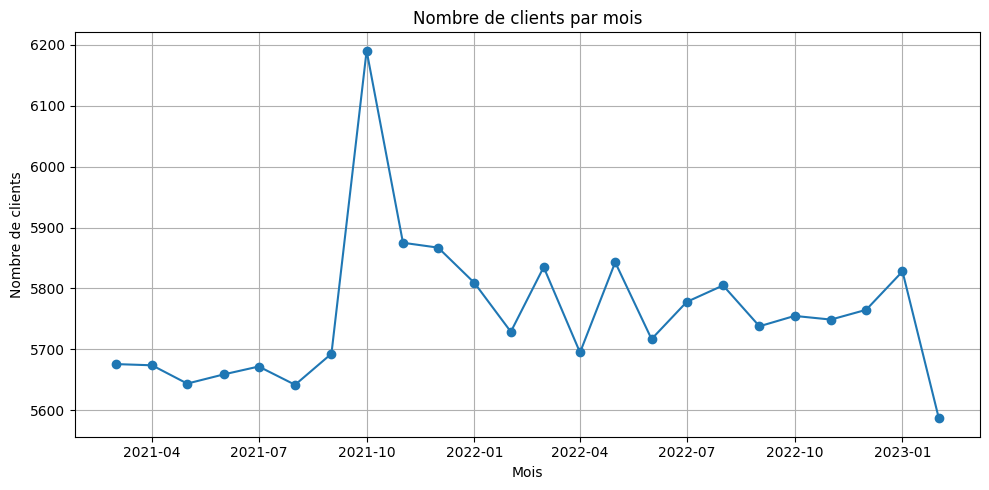

In [46]:
clients_mois = df_all.groupby(df_all["date"].dt.to_period("M"))["client_id"].nunique()
clients_mois = clients_mois.reset_index()
clients_mois.columns = ["mois", "nb_clients"]

clients_mois["mois"] = clients_mois["mois"].astype(str)
clients_mois["mois"] = pd.to_datetime(clients_mois["mois"])

plt.figure(figsize=(10, 5))
plt.plot(clients_mois["mois"], clients_mois["nb_clients"], marker="o")

plt.title("Nombre de clients par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de clients")
plt.grid(True)
plt.tight_layout()
plt.show()

In [47]:
nb_transactions = len(df_all)
print(nb_transactions)

transactions_mois = df_all.groupby(df_all["date"].dt.to_period("M"))["session_id"].count()
transactions_mois = transactions_mois.reset_index()
transactions_mois.columns = ["mois", "nb_transactions"]

print(transactions_mois)


687534
       mois  nb_transactions
0   2021-03            28601
1   2021-04            28443
2   2021-05            28285
3   2021-06            26850
4   2021-07            24738
5   2021-08            25650
6   2021-09            33314
7   2021-10            30022
8   2021-11            28311
9   2021-12            32457
10  2022-01            29343
11  2022-02            29594
12  2022-03            29696
13  2022-04            27602
14  2022-05            29975
15  2022-06            28504
16  2022-07            28670
17  2022-08            28544
18  2022-09            28306
19  2022-10            28964
20  2022-11            28563
21  2022-12            28619
22  2023-01            28938
23  2023-02            25545


In [48]:
transactions_categ = df_all.groupby("categ")["session_id"].count()

print(transactions_categ)

categ
0    415459
1    235592
2     36483
Name: session_id, dtype: int64


In [49]:
tops = df_all.groupby("id_prod")["session_id"].count().sort_values(ascending=False)
flops = df_all.groupby("id_prod")["session_id"].count().sort_values()

print(flops.head(10))
print(tops.head(10))

id_prod
2_98      1
2_81      1
0_833     1
0_1728    1
2_23      1
0_1683    1
0_1498    1
0_2201    1
0_1284    1
0_807     1
Name: session_id, dtype: int64
id_prod
1_369    2340
1_417    2269
1_414    2246
1_498    2202
1_425    2163
1_403    2040
1_413    2036
1_412    2014
1_406    2003
1_407    2001
Name: session_id, dtype: int64


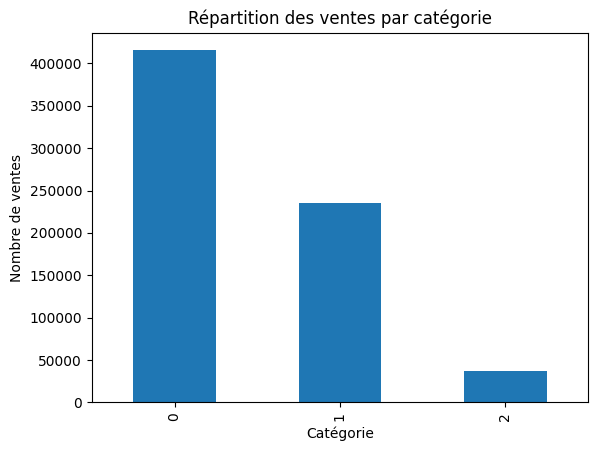

In [50]:
repartition_categ = df_all.groupby("categ")["session_id"].count().reset_index()
repartition_categ.columns = ["categorie", "nb_ventes"]

repartition_categ.plot(
    x="categorie",
    y="nb_ventes",
    kind="bar",
    legend=False
)

plt.title("Répartition des ventes par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de ventes")

plt.show()

In [51]:
top_ca = df_all.groupby("id_prod")["price"].sum().sort_values(ascending=False)

print(top_ca.head(10))


id_prod
2_159    94893.50
2_135    69334.95
2_112    65407.76
2_102    60736.78
2_209    56971.86
1_395    56617.47
1_369    56136.60
2_110    53846.25
1_383    53834.43
1_414    53522.18
Name: price, dtype: float64


In [52]:
ca_client = df_all.groupby("client_id")["price"].sum()

ca_client = ca_client.reset_index()
ca_client.columns = ["client_id", "ca"]

ca_client = ca_client.sort_values(by="ca")

ca_client["ca_cumule"] = ca_client["ca"].cumsum()
ca_client["part_ca"] = ca_client["ca_cumule"] / ca_client["ca"].sum()

ca_client["part_clients"] = np.arange(1, len(ca_client)+1) / len(ca_client)

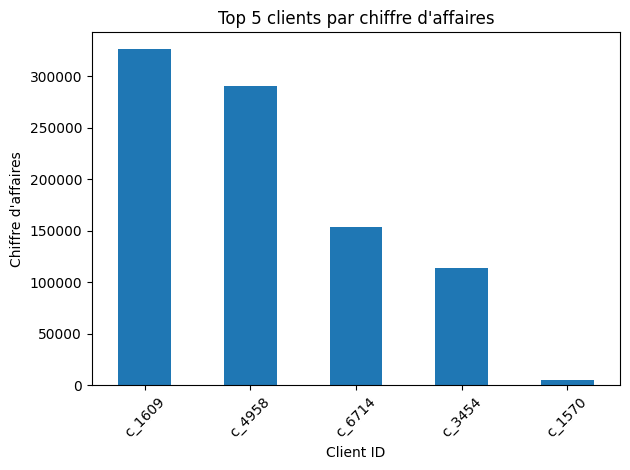

In [53]:
top_client = (
    ca_client.groupby("client_id")["ca"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

# Graphique
plt.figure()
top_client.plot(kind="bar")

plt.title("Top 5 clients par chiffre d'affaires")
plt.xlabel("Client ID")
plt.ylabel("Chiffre d'affaires")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

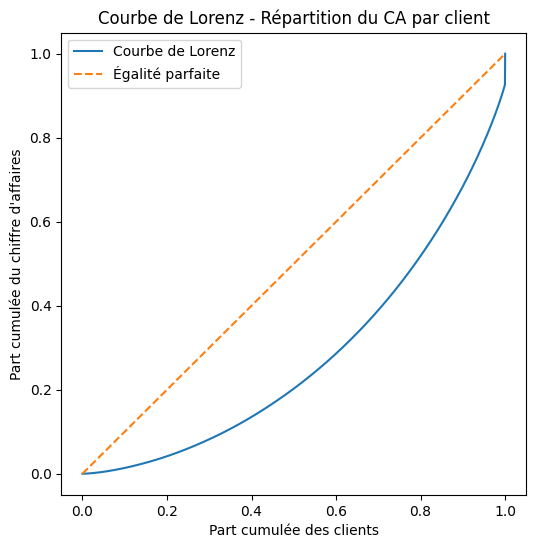

In [54]:
plt.figure(figsize=(6,6))

plt.plot(ca_client["part_clients"], ca_client["part_ca"], label="Courbe de Lorenz")
plt.plot([0,1],[0,1], linestyle="--", label="Égalité parfaite")

plt.xlabel("Part cumulée des clients")
plt.ylabel("Part cumulée du chiffre d'affaires")

plt.title("Courbe de Lorenz - Répartition du CA par client")

plt.legend()
plt.show()

In [55]:
gini = 1 - 2 * np.trapz(ca_client["part_ca"], ca_client["part_clients"])
print(gini)

0.4418958800171595


C:\Users\User\AppData\Local\Temp\ipykernel_28900\2678388147.py:1: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(ca_client["part_ca"], ca_client["part_clients"])


In [56]:
df_all["age"] = 2024 - df_all["birth"]


valeur = [0, 25, 35, 45, 55, 65, 100]
labels = ["<25", "25-35", "35-45", "45-55", "55-65", "65+"]

df_all["tranche_age"] = pd.cut(df_all["age"], bins=valeur, labels=labels)

df_all["ca"] = df_all["price"]

ca_age_produit = df_all.groupby(["tranche_age", "id_prod"])["ca"].sum()

print(ca_age_produit)

tranche_age  id_prod
<25          0_0         90.00
             0_1         43.96
             0_10         0.00
             0_100        0.00
             0_1000      41.04
                         ...  
65+          2_95        98.99
             2_96       862.38
             2_97         0.00
             2_98         0.00
             2_99         0.00
Name: ca, Length: 19590, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_28900\2364181853.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ca_age_produit = df_all.groupby(["tranche_age", "id_prod"])["ca"].sum()


tranche_age
<25      1825114.03
25-35    2198103.03
35-45    3155693.34
45-55    2336609.33
55-65    1341351.95
65+      1170791.42
Name: ca, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_28900\3040100849.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ca_age = df_all.groupby("tranche_age")["ca"].sum()


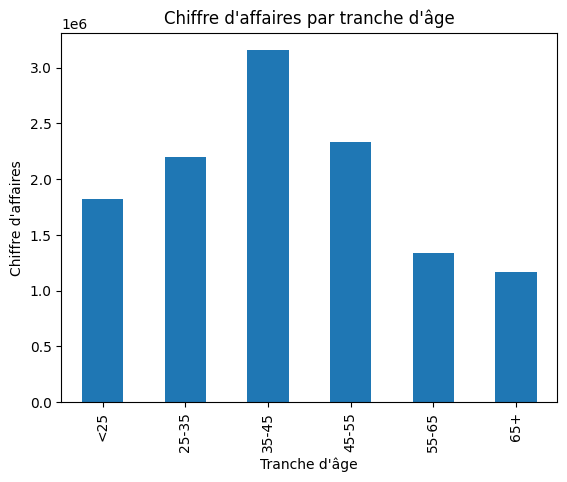

In [57]:
ca_age = df_all.groupby("tranche_age")["ca"].sum()

print(ca_age)

ca_age.plot(kind="bar")

plt.title("Chiffre d'affaires par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Chiffre d'affaires")

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_28900\97435174.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ca_age_categ = df_all.groupby(["tranche_age", "categ"])["ca"].sum()


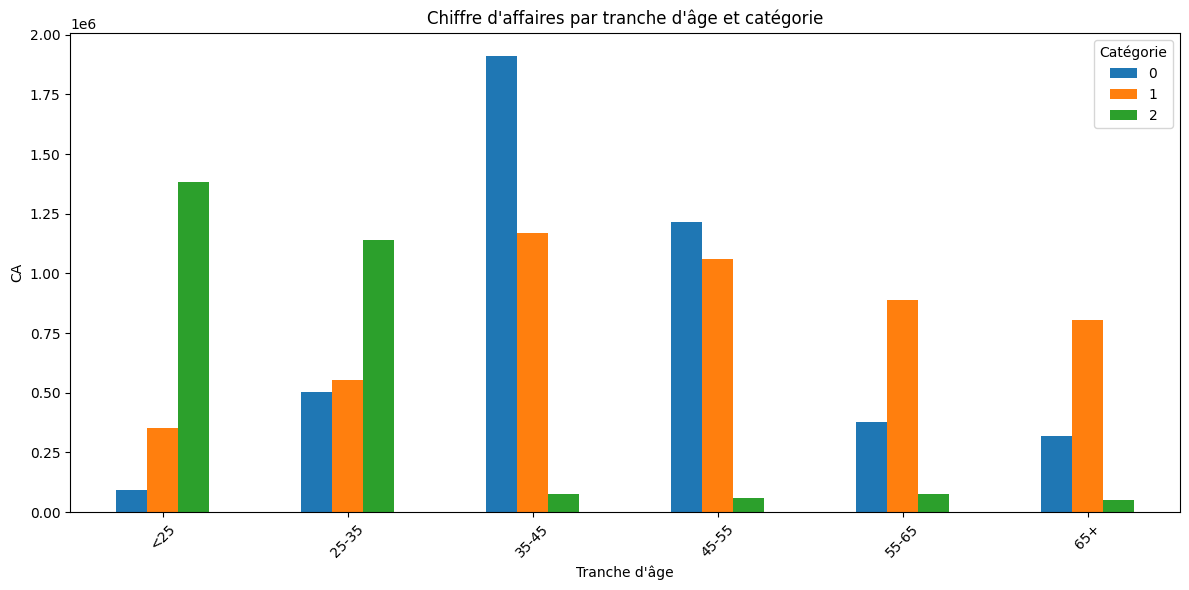

In [58]:
ca_age_categ = df_all.groupby(["tranche_age", "categ"])["ca"].sum()


ca_age_categ.unstack().plot(kind='bar', figsize=(12, 6))
plt.title('Chiffre d\'affaires par tranche d\'âge et catégorie')
plt.xlabel('Tranche d\'âge')
plt.ylabel('CA')
plt.legend(title='Catégorie')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Chi2: 158.25417617304882
p-value: 4.3205822283997063e-35
Relation significative (variables dépendantes)
0.015171569112675852


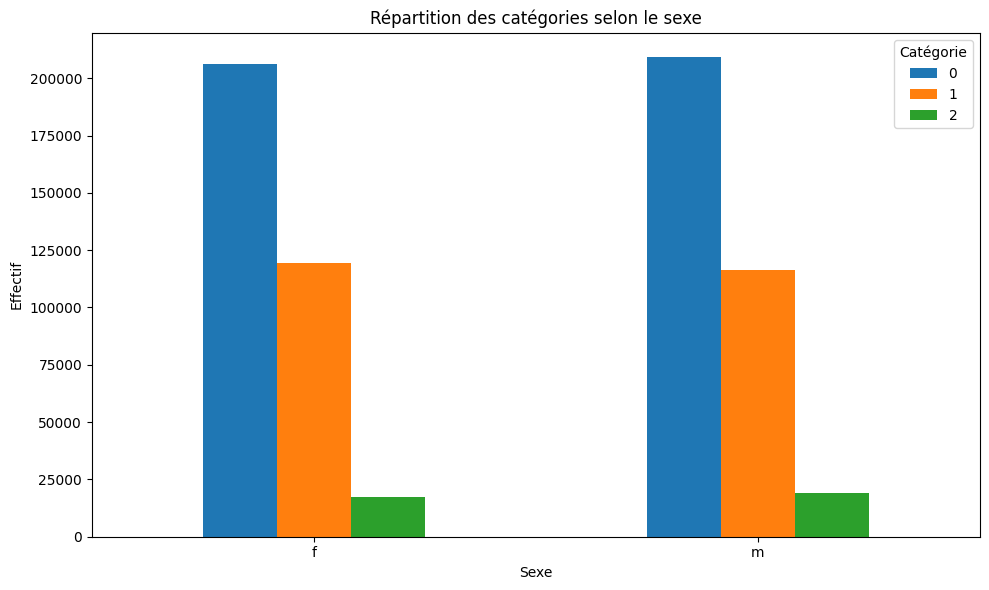

In [59]:
from scipy.stats import chi2_contingency


sex_categ = pd.crosstab(df_all['sex'], df_all['categ'])


chi2, p, dof, expected = chi2_contingency(sex_categ)

print(f"Chi2: {chi2}")
print(f"p-value: {p}")


alpha = 0.05
if p > alpha:
    print("Pas de relation significative (variables indépendantes)")
else:
    print("Relation significative (variables dépendantes)")


n = sex_categ.values.sum()
cramer_v = np.sqrt(chi2 / (n * (min(sex_categ.shape)-1)))

print(cramer_v)

sex_categ.plot(kind='bar', figsize=(10,6))

plt.title("Répartition des catégories selon le sexe")
plt.xlabel("Sexe")
plt.ylabel("Effectif")
plt.xticks(rotation=0)
plt.legend(title="Catégorie")
plt.tight_layout()

plt.show()

Corrélation de Spearman : -0.1715122732240436
p-value : 0.0


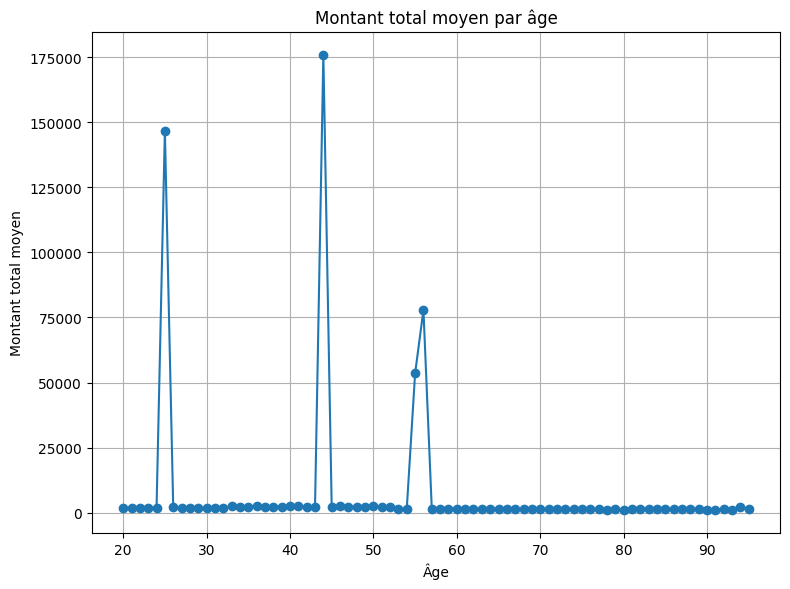

In [69]:
from scipy.stats import spearmanr
df_all['montant_total'] = df_all.groupby("client_id")["price"].transform('sum')
corr, p = spearmanr(df_all['age'], df_all['montant_total'])

print("Corrélation de Spearman :", corr)
print("p-value :", p)

# ----- GRAPHIQUE -----
age_mean = df_all.groupby('age')['montant_total'].mean().reset_index()

plt.figure(figsize=(8,6))

plt.plot(age_mean['age'],
         age_mean['montant_total'],
         marker='o')

plt.title("Montant total moyen par âge")
plt.xlabel("Âge")
plt.ylabel("Montant total moyen")

plt.grid(True)
plt.tight_layout()

plt.show()

Corrélation: 0.12751586000609932
p-value: 1.652508672647626e-32


C:\Users\User\AppData\Local\Temp\ipykernel_28900\436314889.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_client.groupby(pd.cut(df_client['age'], bins=5))['frequence'].mean()
C:\Users\User\AppData\Local\Temp\ipykernel_28900\436314889.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.cut(df_client['age'], bins=5))['frequence']


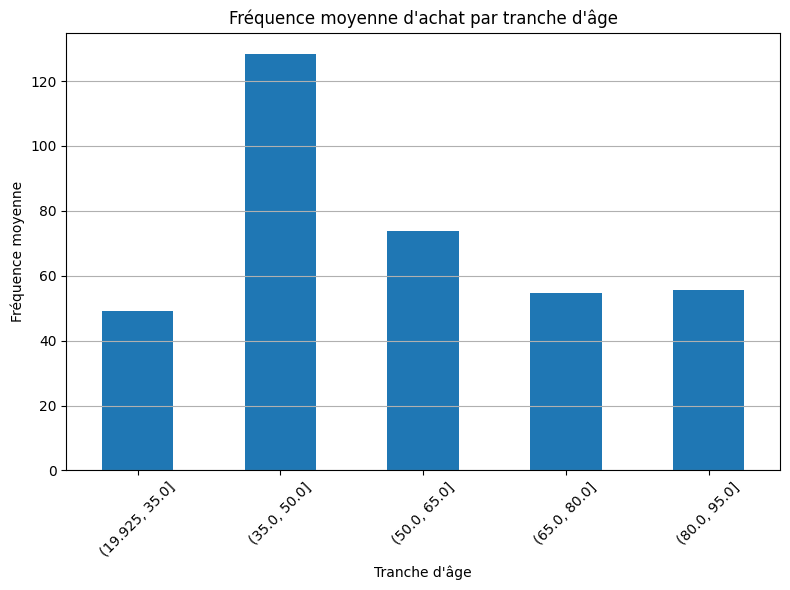

In [70]:
freq = df_all.groupby("client_id")["price"].count()


df_client = df_all[['client_id', 'age']].drop_duplicates()

df_client['frequence'] = df_client['client_id'].map(freq)


corr, p = spearmanr(df_client['age'], df_client['frequence'])

print("Corrélation:", corr)
print("p-value:", p)

df_client.groupby(pd.cut(df_client['age'], bins=5))['frequence'].mean()

freq_age = (
    df_client
    .groupby(pd.cut(df_client['age'], bins=5))['frequence']
    .mean()
)

# Graphique
plt.figure(figsize=(8,6))

freq_age.plot(kind='bar')

plt.title("Fréquence moyenne d'achat par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Fréquence moyenne")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

Corrélation: -0.3258367629603617
p-value: 7.363415077094605e-212


C:\Users\User\AppData\Local\Temp\ipykernel_28900\326657670.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_client.groupby('age_bin')['panier_moyen'].mean()
C:\Users\User\AppData\Local\Temp\ipykernel_28900\326657670.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_bin')['panier_moyen']


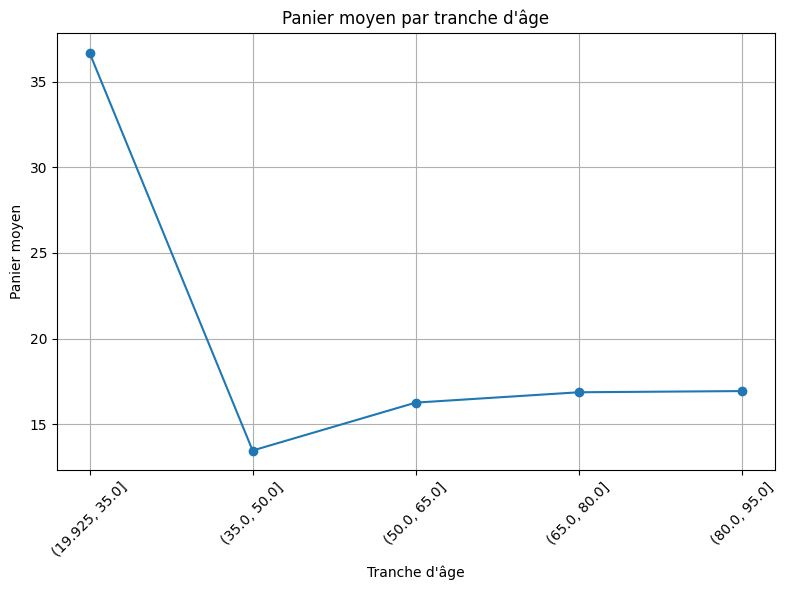

In [71]:
panier_moyen = df_all.groupby("client_id")["price"].mean()

df_client = df_all[['client_id', 'age']].drop_duplicates()

df_client['panier_moyen'] = df_client['client_id'].map(panier_moyen)

corr, p = spearmanr(df_client['age'], df_client['panier_moyen'])

print("Corrélation:", corr)
print("p-value:", p)

df_client['age_bin'] = pd.cut(df_client['age'], bins=5)

df_client.groupby('age_bin')['panier_moyen'].mean()

panier_age = (
    df_client
    .groupby('age_bin')['panier_moyen']
    .mean()
)

# Graphique
plt.figure(figsize=(8,6))

plt.plot(
    panier_age.index.astype(str),
    panier_age.values,
    marker='o'
)

plt.title("Panier moyen par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Panier moyen")

plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

F-stat: 45120.03553567387
p-value: 0.0


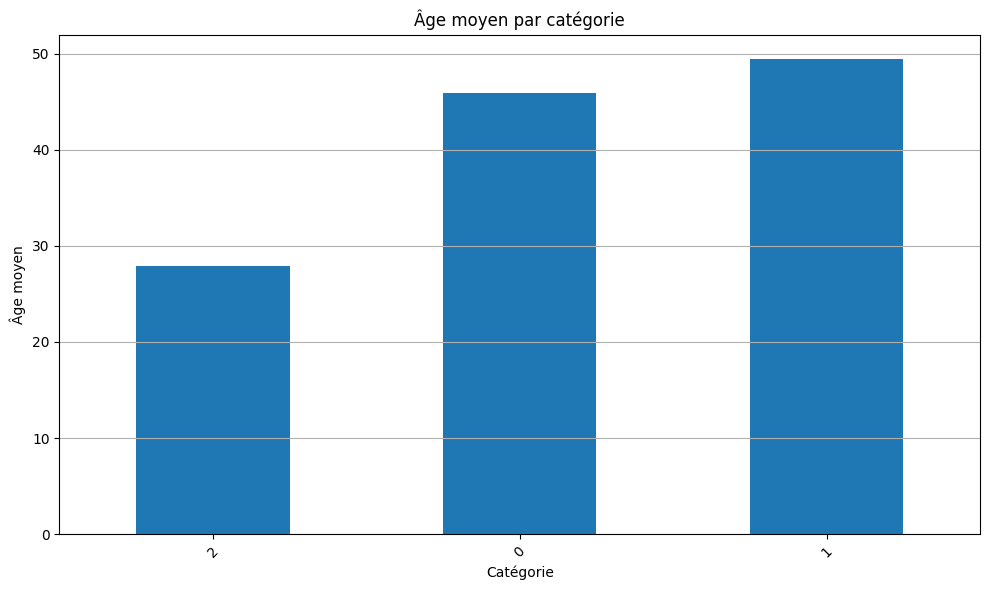

In [72]:
from scipy.stats import f_oneway


groups = [group["age"].values for name, group in df_all.groupby("categ")]

stat, p = f_oneway(*groups)

print("F-stat:", stat)
print("p-value:", p)

# Moyenne d'âge par catégorie
age_moyen = (
    df_all
    .groupby('categ')['age']
    .mean()
    .sort_values()
)

# Graphique
plt.figure(figsize=(10,6))

age_moyen.plot(kind='bar')

plt.title("Âge moyen par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Âge moyen")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

In [33]:
print(df_all)

       id_prod                       date session_id client_id sex  birth  \
0       0_1259 2021-03-01 00:01:07.843138        s_1     c_329   f   1967   
1       0_1390 2021-03-01 00:02:26.047414        s_2     c_664   m   1960   
2       0_1352 2021-03-01 00:02:38.311413        s_3     c_580   m   1988   
3       0_1458 2021-03-01 00:04:54.559692        s_4    c_7912   f   1989   
4       0_1358 2021-03-01 00:05:18.801198        s_5    c_2033   f   1956   
...        ...                        ...        ...       ...  ..    ...   
687529   1_508 2023-02-28 23:49:03.148402   s_348444    c_3573   f   1996   
687530    2_37 2023-02-28 23:51:29.318531   s_348445      c_50   f   1994   
687531   1_695 2023-02-28 23:53:18.929676   s_348446     c_488   f   1985   
687532  0_1547 2023-02-28 23:58:00.107815   s_348447    c_4848   m   1953   
687533  0_1398 2023-02-28 23:58:30.792755   s_348435    c_3575   f   1981   

        age  price  categ     ca tranche_age  montant_total  
0        57  